In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
ruta_train=Path("../data/2.processed/train_processed.csv").resolve()
ruta_test=Path("../data/2.processed/test_processed.csv").resolve()
df_train=pd.read_csv(ruta_train,sep=',')
df_test=pd.read_csv(ruta_test,sep=',')
df_train['date']=pd.to_datetime(df_train['date'],format='%Y-%m-%d')
df_test['date']=pd.to_datetime(df_test['date'],format='%Y-%m-%d')

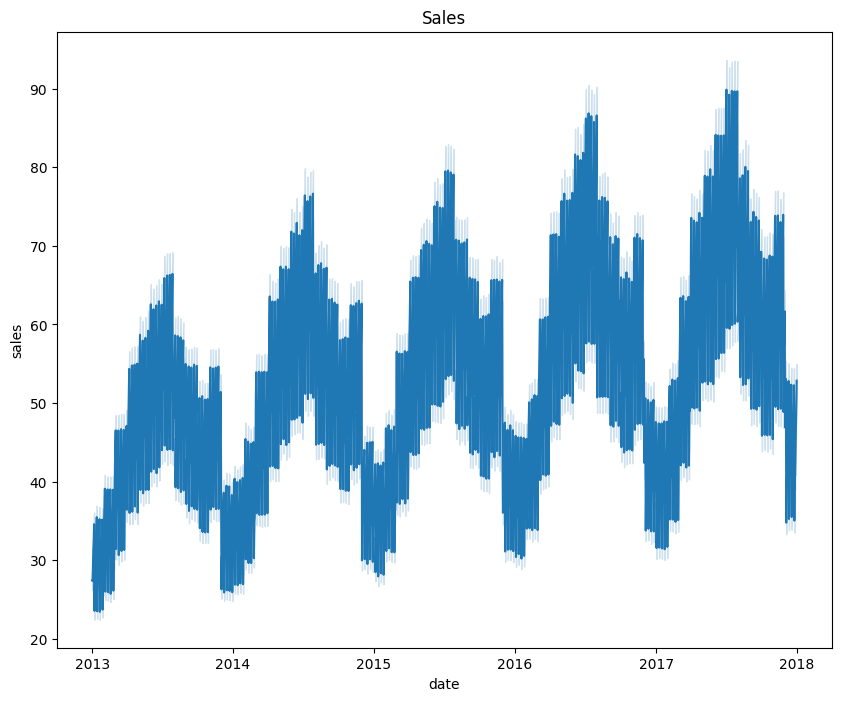

In [ ]:
plt.figure(figsize=(10,8))
sns.lineplot(data=df_train,x='date',y='sales')
plt.title(f'Sales')
plt.show()

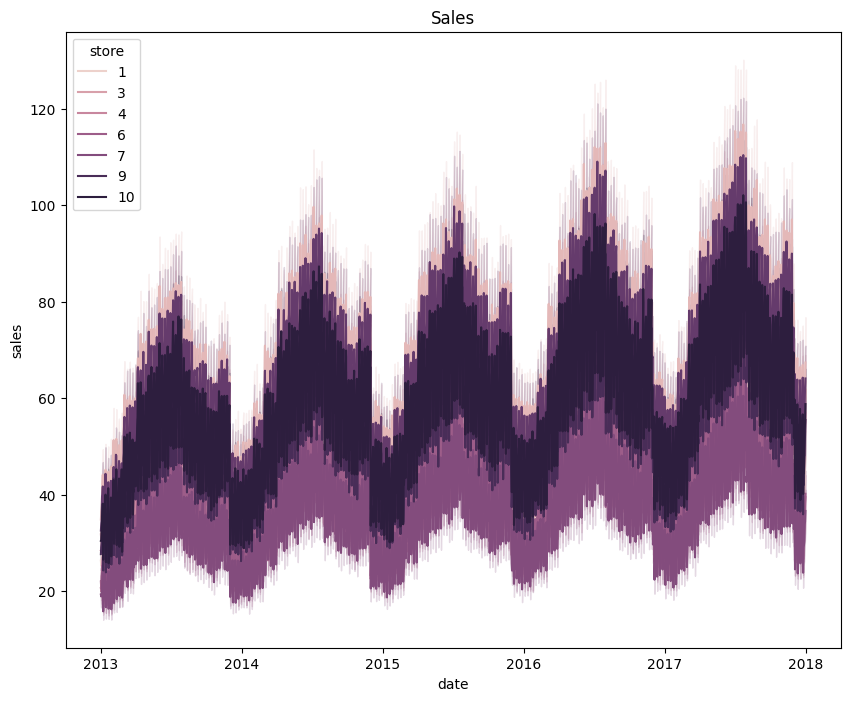

In [14]:
plt.figure(figsize=(10,8))
sns.lineplot(data=df_train,x='date',y='sales',hue='store')
plt.title(f'Sales')
plt.show()

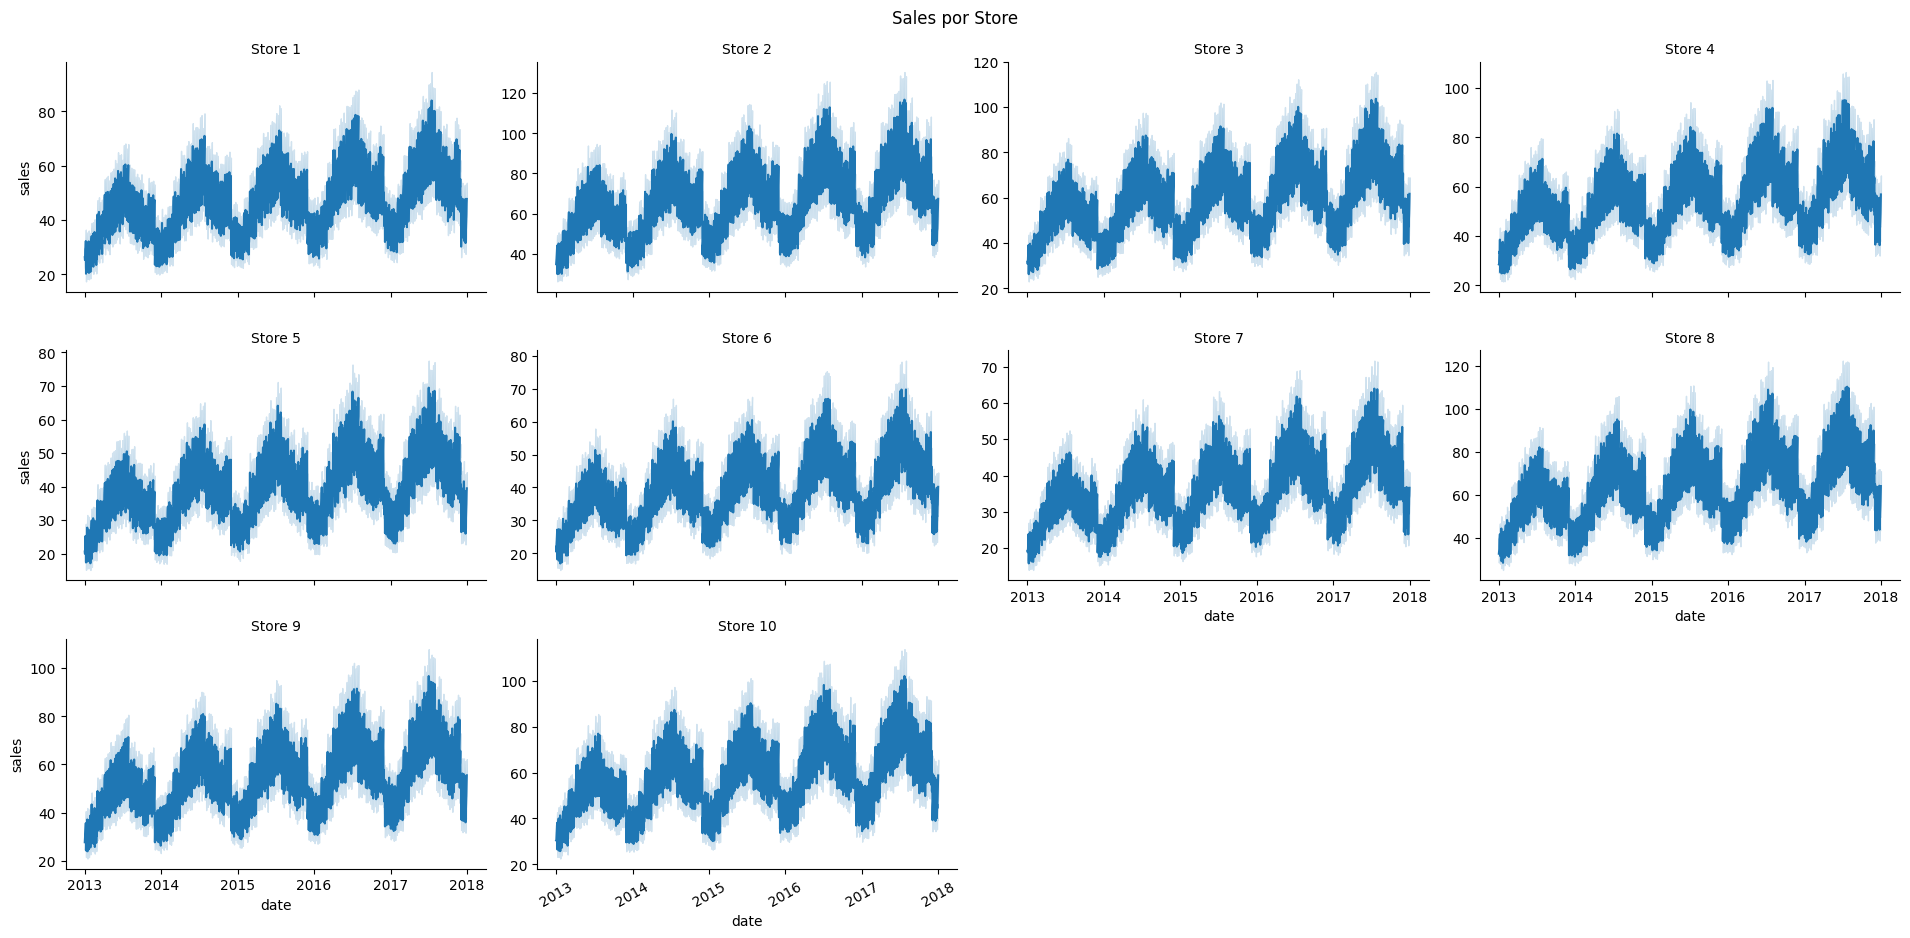

In [4]:
# col_wrap=4 -> 4 gráficos por fila, cámbialo según cuántas tiendas tengas
g = sns.relplot(
    data=df_train,
    x='date', y='sales',
    col='store',
    col_wrap=4,
    kind='line',
    height=3, aspect=1.6,
    facet_kws={'sharey': False} # pon True si quieres comparar en la misma escala
)
g.set_titles("Store {col_name}")
g.fig.suptitle('Sales por Store', y=1.02)
plt.xticks(rotation=30)
plt.show()

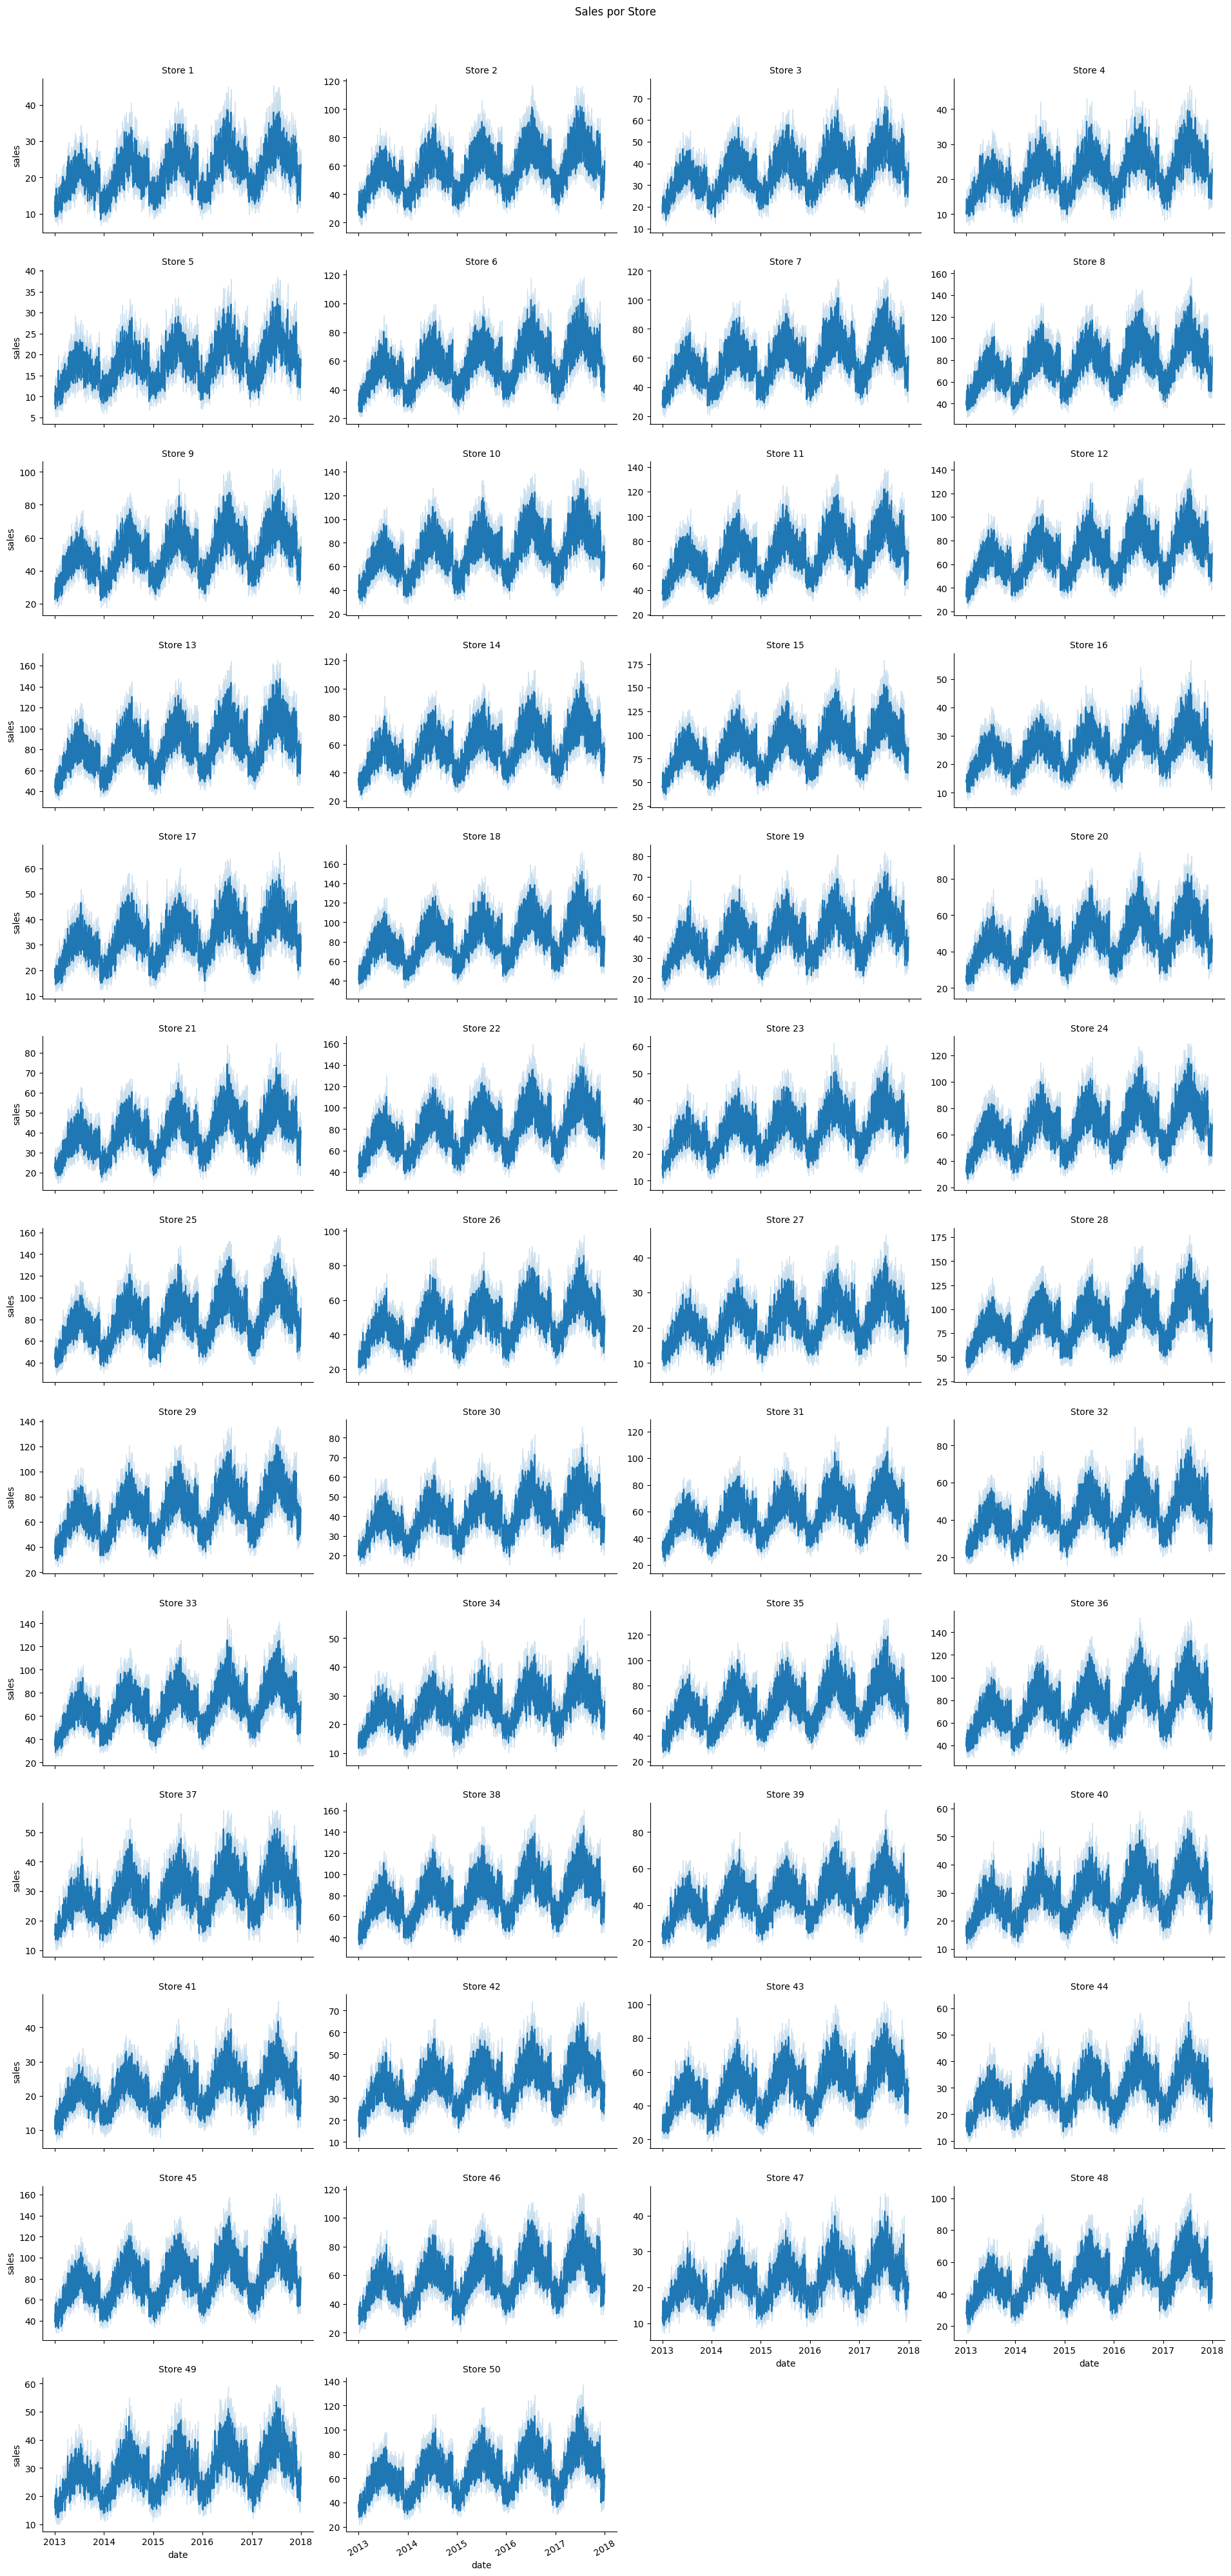

In [10]:
# col_wrap=4 -> 4 gráficos por fila, cámbialo según cuántas tiendas tengas
g = sns.relplot(
    data=df_train,
    x='date', y='sales',
    col='item',
    col_wrap=4,
    kind='line',
    height=3, aspect=1.6,
    facet_kws={'sharey': False} # pon True si quieres comparar en la misma escala
)
g.set_titles("Item {col_name}")
g.fig.suptitle('Sales por Item', y=1.02)
plt.xticks(rotation=30)
plt.show()

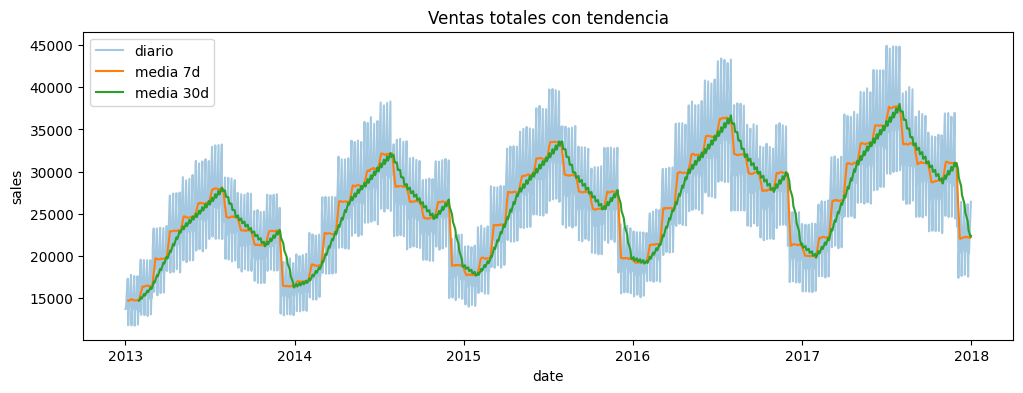

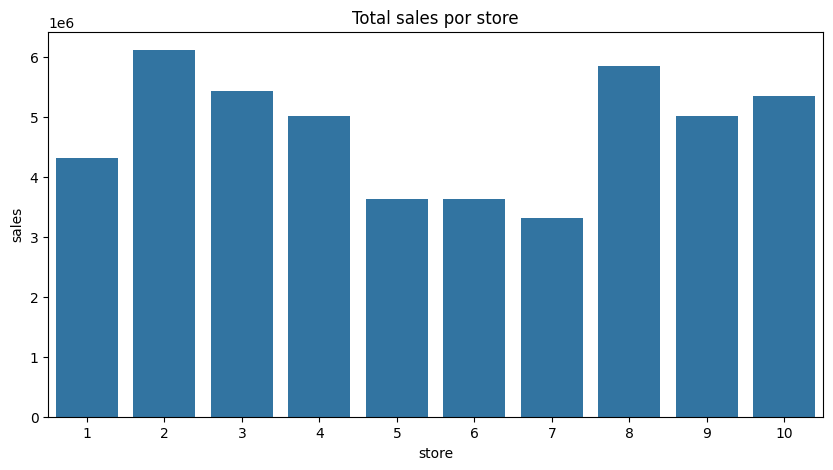

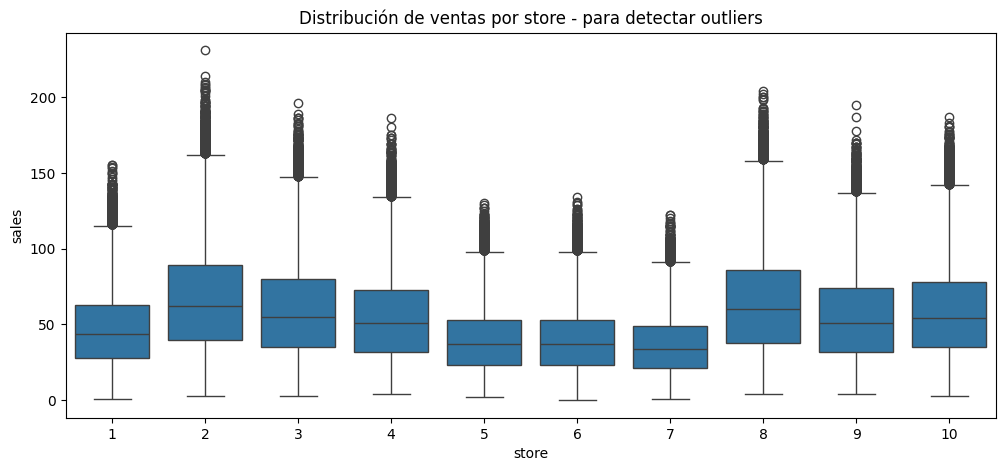

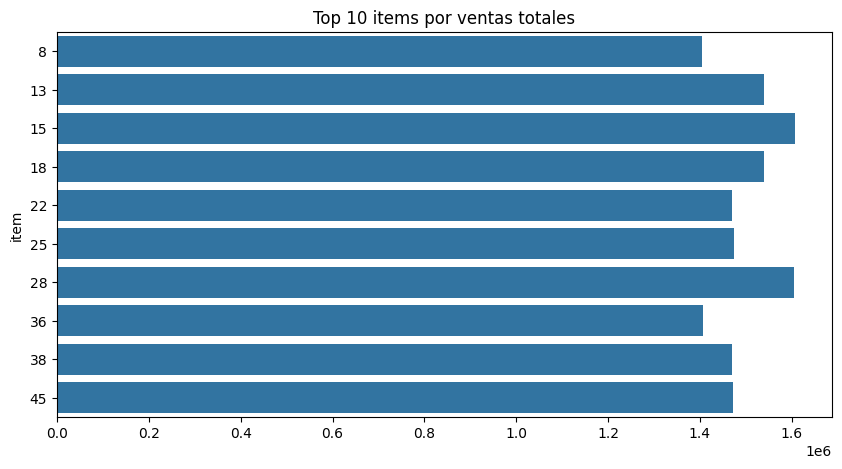

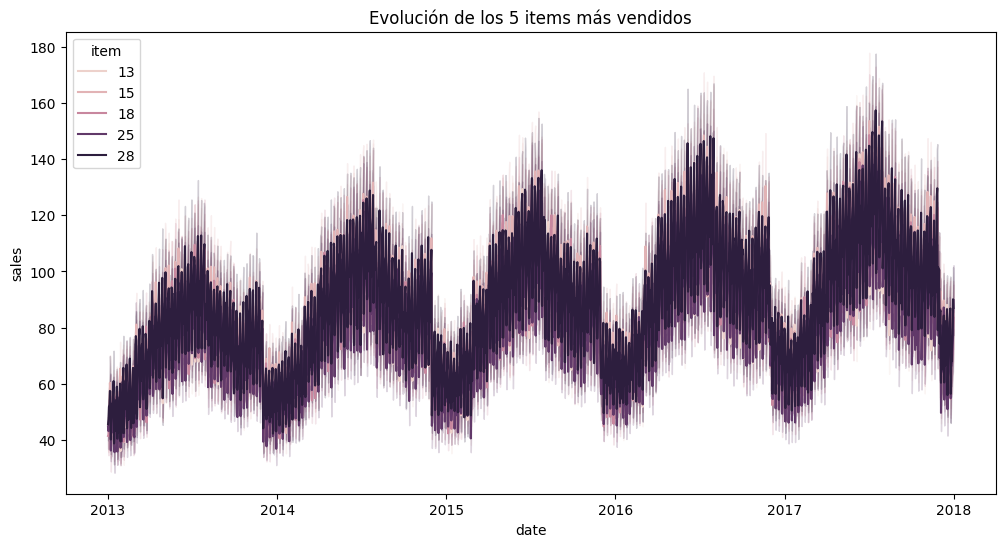

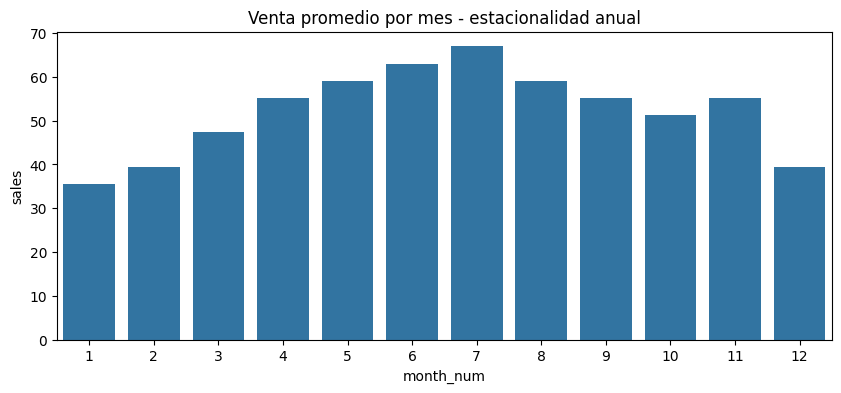

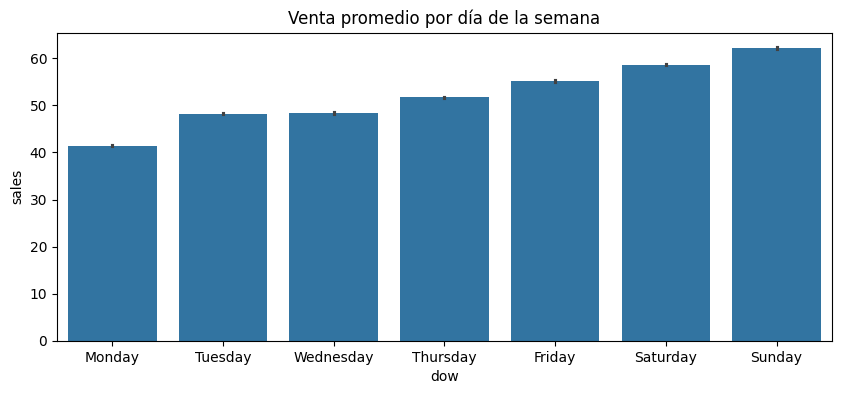

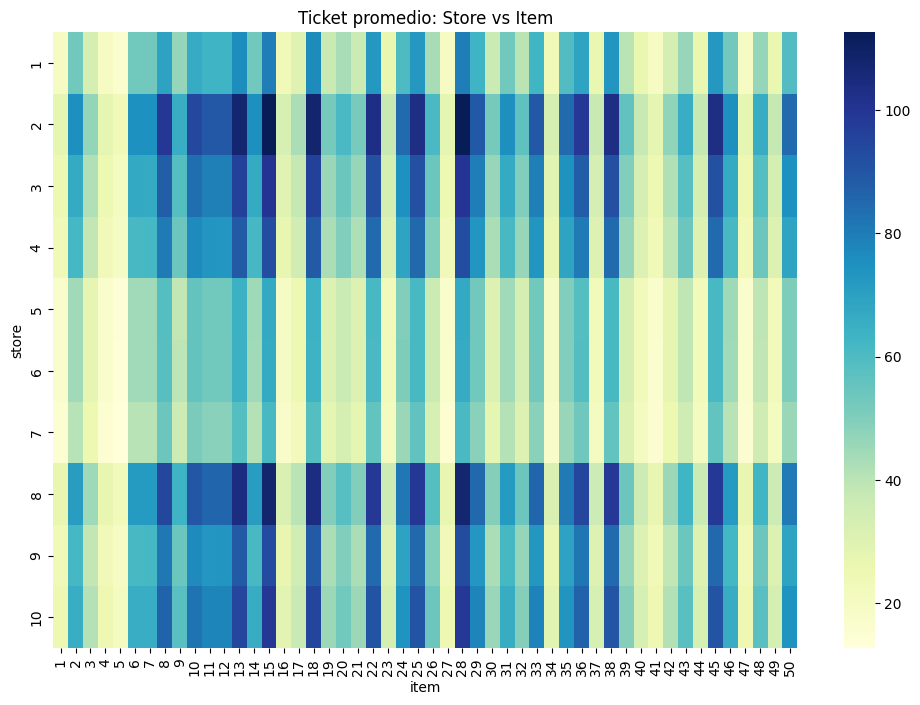

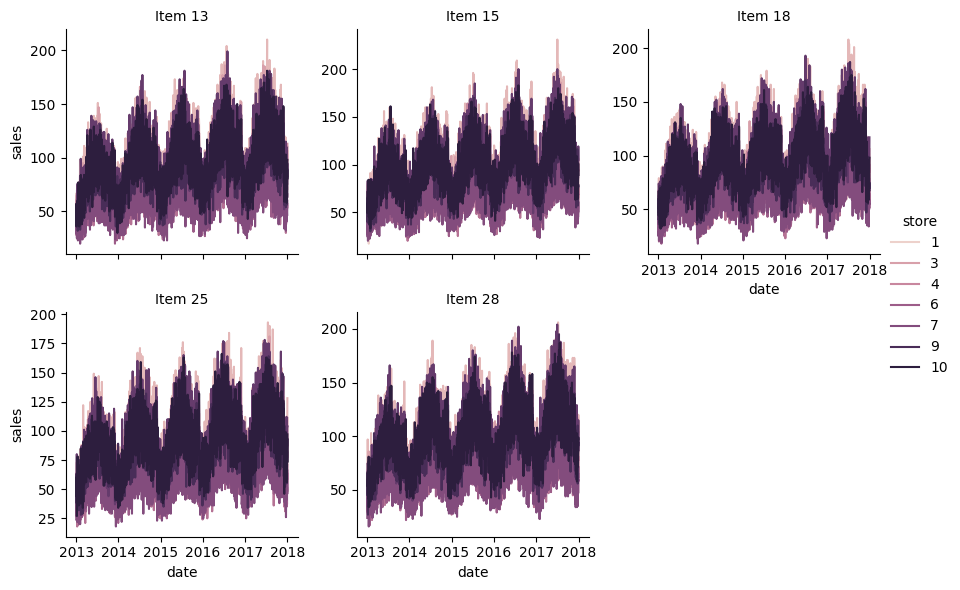

In [18]:
df_train['month'] = df_train['date'].dt.to_period('M').astype(str)
df_train['month_num'] = df_train['date'].dt.month
df_train['dow'] = df_train['date'].dt.day_name()
df_train['dow_num'] = df_train['date'].dt.dayofweek

# Tendencia total + promedio movil

daily = df_train.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(12,4))
sns.lineplot(data=daily, x='date', y='sales', alpha=0.4, label='diario')
daily['rolling_7'] = daily['sales'].rolling(7).mean()
daily['rolling_30'] = daily['sales'].rolling(30).mean()
plt.plot(daily['date'], daily['rolling_7'], label='media 7d')
plt.plot(daily['date'], daily['rolling_30'], label='media 30d')
plt.title('Ventas totales con tendencia')
plt.legend()
plt.show()

# Ranking de tiendas
plt.figure(figsize=(10,5))
sns.barplot(data=df_train.groupby('store')['sales'].sum().reset_index().sort_values('sales', ascending=False), 
            x='store', y='sales')
plt.title('Total sales por store')
plt.show()

# Distribución por tienda
plt.figure(figsize=(12,5))
sns.boxplot(data=df_train, x='store', y='sales')
plt.title('Distribución de ventas por store - para detectar outliers')
plt.show()

# Que itens mueven el negocio el 80/20
top_items = df_train.groupby('item')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_items.values, y=top_items.index, orient='h')
plt.title('Top 10 items por ventas totales')
plt.show()


top_5 = df_train.groupby('item')['sales'].sum().nlargest(5).index
df_top = df_train[df_train['item'].isin(top_5)]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_top, x='date', y='sales', hue='item')
plt.title('Evolución de los 5 items más vendidos')
plt.show()


# Estacionalidad - por mes y por día de la semana

plt.figure(figsize=(10,4))
sns.barplot(data=df_train.groupby('month_num')['sales'].mean().reset_index(), x='month_num', y='sales')
plt.title('Venta promedio por mes - estacionalidad anual')
plt.show()

plt.figure(figsize=(10,4))
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.barplot(data=df_train, x='dow', y='sales', order=order, estimator='mean')
plt.title('Venta promedio por día de la semana')
plt.show()

# Heatmap Store vs Item 
pivot = df_train.pivot_table(index='store', columns='item', values='sales', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title('Ticket promedio: Store vs Item')
plt.show()

# La evolución de cada iten dentro de cada store
# Usa relplot para facetear por item y colorear por store, o viceversa
g = sns.relplot(
    data=df_train[df_train['item'].isin(top_5)], # filtra para que sea legible
    x='date', y='sales',
    col='item', col_wrap=3,
    hue='store',
    kind='line', height=3, facet_kws={'sharey': False}
)
g.set_titles("Item {col_name}")
plt.show()
